# Chapter 52 — Functions as Programs

> **Prerequisites:** ch051 (What is a Function?), ch003 (Abstraction)
> 
> **You will learn:**
> - The precise correspondence between mathematical functions and Python functions
> - Pure functions vs impure functions, and why purity matters mathematically
> - Higher-order functions: map, filter, reduce as mathematical operations
> - Lambda calculus intuition: functions as the universal building block
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In ch051 we defined a function mathematically. Now we ask: what is the relationship between a *mathematical function* and a *program function*?

**The correspondence is exact for pure functions.**

A **pure function** in programming:
- Takes inputs, returns output
- No side effects (no printing, no file writing, no modifying global state)
- Deterministic: same input → same output, always

This is literally the definition of a mathematical function. A pure Python function `def f(x): return x**2` *is* the function f(x) = x².

**Where they diverge:** Programming functions can be *impure* — they can read from files, use randomness, modify global state, print to screen. A mathematical function cannot. When a function takes a timestamp as input and returns it, it is pure. When it reads the current time and returns it, it is not.

**Why this matters:** Mathematical analysis tools (derivatives, limits, composition, inversion) work on pure functions. If your program function has side effects, you cannot apply mathematical reasoning to it.

---

## 2. Intuition & Mental Models

**Physical analogy:** A mathematical function is like a sealed black box — you feed in a number, it produces a number. No memory, no state, no history. A pure Python function is the same sealed box. An impure function is a box with a window to the outside — it can peek at the world and produce different outputs even for the same input.

**Computational analogy:** In functional programming languages (Haskell, Erlang), all functions are pure by default. This makes them behave exactly like mathematical functions. Python allows both, which is powerful but requires discipline.

Think of `map(f, [1,2,3,4])` as applying f to each element of a set: `{f(1), f(2), f(3), f(4)}`. This is exactly the set-theoretic *image* of a set under a function — introduced in ch051.

**Lambda calculus intuition:** Every computable function can be expressed as a combination of input-output mappings. The `lambda` keyword in Python is a direct reference to this. `lambda x: x**2` and `def f(x): return x**2` define the same function — they are two syntactic representations of one mathematical object.

---

## 3. Visualization

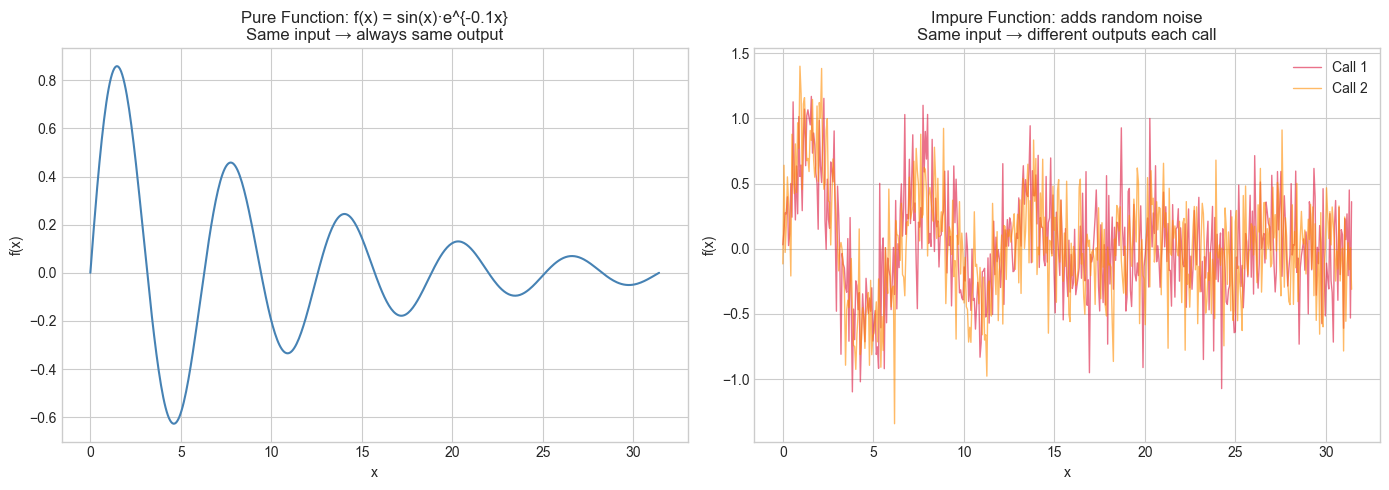

In [1]:
# --- Visualization: Pure vs Impure Functions and their mathematical equivalents ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Demonstrating that pure functions produce consistent, plottable surfaces
# while impure functions do not.

# Pure function: same x → same y, always
def pure_f(x):
    return np.sin(x) * np.exp(-0.1 * x)

x = np.linspace(0, 10 * np.pi, 500)
y_pure = pure_f(x)

# Impure function: same x → different y (random noise added)
# This is NOT a mathematical function — it is non-deterministic.
def impure_f(x):
    return np.sin(x) * np.exp(-0.1 * x) + np.random.normal(0, 0.3)

# Call impure 3 times at same x — get 3 different "outputs"
y_impure_1 = np.array([impure_f(xi) for xi in x])
y_impure_2 = np.array([impure_f(xi) for xi in x])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, y_pure, color='steelblue', linewidth=1.5)
axes[0].set_title('Pure Function: f(x) = sin(x)·e^{-0.1x}\nSame input → always same output')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')

axes[1].plot(x, y_impure_1, color='crimson', alpha=0.6, linewidth=1, label='Call 1')
axes[1].plot(x, y_impure_2, color='darkorange', alpha=0.6, linewidth=1, label='Call 2')
axes[1].set_title('Impure Function: adds random noise\nSame input → different outputs each call')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Function as a program — the lambda calculus view:**

In lambda calculus, every function is written:
```
λx. [body]
```
meaning: "a function that takes x and returns [body]".

In Python: `lambda x: body`

**Higher-order functions** are functions that take other functions as input:
- `map(f, S)` computes `{f(x) : x ∈ S}` — the image of set S under f
- `filter(p, S)` computes `{x ∈ S : p(x) is True}` — subset where predicate holds
- `reduce(f, S)` computes `f(f(...f(x1, x2), x3)..., xn)` — fold left

These are set operations expressed as programs.

In [2]:
# --- Mathematical Formulation: Higher-order functions as set operations ---
import numpy as np
from functools import reduce

# The input set S = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
S = list(range(1, 11))

# map: apply f to every element
# Mathematical: { x² : x ∈ S }
squares = list(map(lambda x: x**2, S))
print("map (x²):", squares)

# filter: keep only elements satisfying a predicate
# Mathematical: { x ∈ S : x is even }
evens = list(filter(lambda x: x % 2 == 0, S))
print("filter (even):", evens)

# reduce: fold an operation over the set
# Mathematical: x1 + x2 + ... + xn = Σ xᵢ
total = reduce(lambda acc, x: acc + x, S, 0)
print("reduce (sum):", total)

# Composing: sum of squares of even numbers
# Mathematical: Σ { x² : x ∈ S, x even }
result = reduce(lambda acc, x: acc + x,
                map(lambda x: x**2,
                    filter(lambda x: x % 2 == 0, S)), 0)
print("Sum of squares of evens:", result)  # 4+16+36+64+100 = 220

# Verify:
print("Verify with numpy:", sum(x**2 for x in range(1,11) if x % 2 == 0))

map (x²): [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
filter (even): [2, 4, 6, 8, 10]
reduce (sum): 55
Sum of squares of evens: 220
Verify with numpy: 220


---

## 5. Python Implementation

In [3]:
# --- Implementation: Function utilities — memoization and profiling ---
import numpy as np
import time

def memoize(f):
    """
    Memoize a pure function: cache results so each input is only computed once.
    
    Mathematically valid ONLY for pure functions — since f(x) is always the same,
    we can safely cache it. For impure functions, memoization would give wrong results.
    
    Args:
        f: callable, a pure function
    Returns:
        callable: memoized version of f
    """
    cache = {}
    def memoized(x):
        if x not in cache:
            cache[x] = f(x)
        return cache[x]
    memoized.cache = cache  # expose for inspection
    return memoized

# Naive recursive Fibonacci — exponential time
def fib(n):
    """Fibonacci sequence: fib(n) = fib(n-1) + fib(n-2), fib(0)=0, fib(1)=1."""
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

# Memoized version — polynomial time
@memoize
def fib_memo(n):
    """Memoized Fibonacci."""
    if n <= 1:
        return n
    return fib_memo(n-1) + fib_memo(n-2)

# Time comparison
N = 30

t0 = time.time()
result_naive = fib(N)
t_naive = time.time() - t0

t0 = time.time()
result_memo = fib_memo(N)
t_memo = time.time() - t0

print(f"fib({N}) = {result_naive}")
print(f"Naive time:    {t_naive:.4f}s")
print(f"Memoized time: {t_memo:.6f}s")
print(f"Speedup: {t_naive/max(t_memo, 1e-9):.1f}x")

# Memoization is sound BECAUSE fib is a pure function.
# The mathematical property (same input → same output) enables this optimization.

fib(30) = 832040
Naive time:    0.2916s
Memoized time: 0.000157s
Speedup: 1858.9x


---

## 6. Experiments

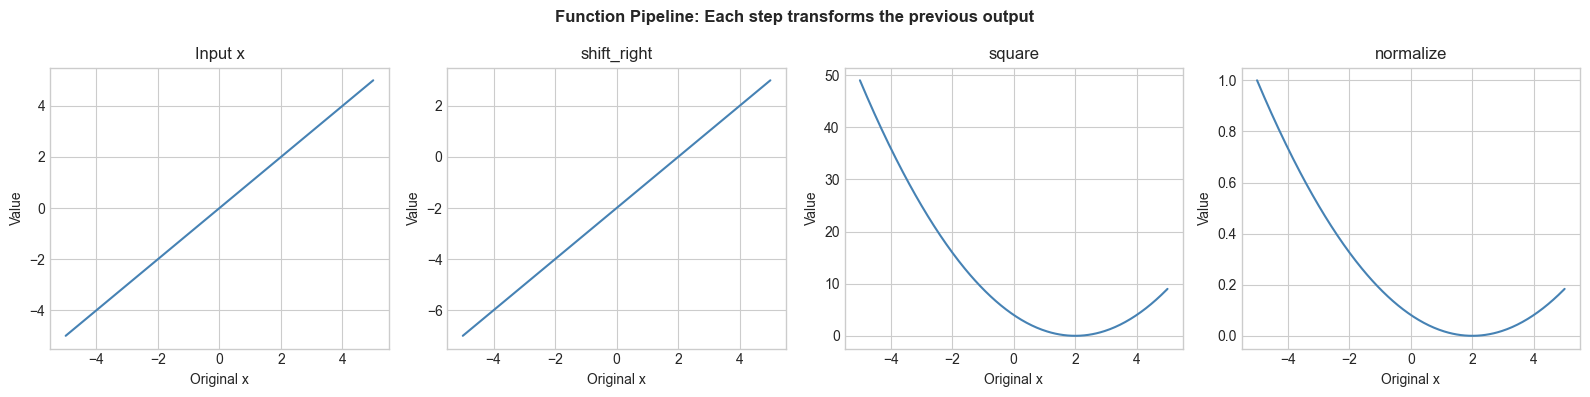

In [4]:
# --- Experiment 1: Function pipeline — composing transformations ---
# Hypothesis: Chaining pure functions produces a predictable composite transformation.
# Try changing: the order of the pipeline steps, or the functions themselves.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Build a pipeline of transformations
pipeline = [
    ('shift_right', lambda x: x - 2),       # x → x - 2
    ('square',      lambda x: x**2),          # x → x²
    ('normalize',   lambda x: x / (x.max() + 1e-8)),  # x → x / max(x)
]

x = np.linspace(-5, 5, 300)
stages = [x]
labels = ['Input x']

current = x.copy()
for name, fn in pipeline:
    current = fn(current)
    stages.append(current.copy())
    labels.append(name)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, stage, label in zip(axes, stages, labels):
    ax.plot(x, stage, color='steelblue', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel('Original x')
    ax.set_ylabel('Value')

plt.suptitle('Function Pipeline: Each step transforms the previous output', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Purity test ---
# Hypothesis: Adding a global state variable to a function makes it impure.
# Try: run the pure and impure versions multiple times and compare outputs.

# IMPURE version — depends on external state
global_bias = 0.0

def impure_add(x):
    """NOT a mathematical function — reads external state."""
    global global_bias
    global_bias += 0.1  # mutates external state
    return x + global_bias

# PURE version
def pure_add(x, bias):
    """Mathematical function — all inputs explicit."""
    return x + bias

print("Calling impure_add(5) three times:")
print(impure_add(5))  # different each time!
print(impure_add(5))
print(impure_add(5))

print("\nCalling pure_add(5, 0.1) three times:")
print(pure_add(5, 0.1))  # same every time
print(pure_add(5, 0.1))
print(pure_add(5, 0.1))

# Lesson: to make an impure function pure, make all its dependencies explicit arguments.

Calling impure_add(5) three times:
5.1
5.2
5.3

Calling pure_add(5, 0.1) three times:
5.1
5.1
5.1


---

## 7. Exercises

**Easy 1.** Is `random.randint(1, 6)` a mathematical function? Why or why not? What change would make it one? *(Expected: no; fix by adding a seed parameter)*

**Easy 2.** Write a pipeline function `compose(*fns)` that takes any number of functions and returns a new function that applies them left-to-right. Test it with `compose(lambda x: x+1, lambda x: x*2, lambda x: x-3)` applied to `5`. *(Expected: a single callable)*

**Medium 1.** Implement `my_map(f, xs)` without using the built-in `map`. Then implement it again using list comprehension. Show they produce identical results for `f = lambda x: x**3` and `xs = range(10)`. *(Hint: iteration)*

**Medium 2.** A function `f` is called **idempotent** if `f(f(x)) = f(x)` for all x. Write a test `is_idempotent(f, test_values)` and verify it holds for `f = lambda x: abs(x)`, `f = lambda x: x**2`, and `f = np.floor`. Which ones are idempotent? *(Hint: floor(floor(x)) = floor(x))*

**Hard.** Implement a general `memoize` decorator that works for functions with multiple arguments (not just one). It should cache based on a tuple of all arguments. Then benchmark it on a recursive function that computes binomial coefficients C(n,k) = C(n-1,k-1) + C(n-1,k) and compare against the naive recursive version. *(Challenge: extend to handle numpy arrays as arguments using a hash)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Functional Data Processing Pipeline ---
# Problem: Process a dataset of temperature readings through a series of
#          pure transformation functions: clean → scale → smooth → analyze.
# Dataset: Simulated hourly temperature data with noise and outliers.
# Task: Build a composable, pure-function pipeline and report key statistics.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# --- Generate dataset ---
np.random.seed(7)
N_HOURS = 168  # one week
true_temp = 20 + 8 * np.sin(2 * np.pi * np.arange(N_HOURS) / 24)  # daily cycle
noisy_temp = true_temp + np.random.normal(0, 1.5, N_HOURS)
# Add outliers
outlier_idx = np.random.choice(N_HOURS, 10, replace=False)
noisy_temp[outlier_idx] += np.random.choice([-15, 15], 10)

# --- Pure transformation functions ---
def remove_outliers(x, z_threshold=2.5):
    """Replace values > z_threshold std deviations from mean with interpolated values."""
    mean, std = x.mean(), x.std()
    cleaned = x.copy()
    mask = np.abs(x - mean) > z_threshold * std
    # Replace outliers with linear interpolation
    indices = np.arange(len(x))
    cleaned[mask] = np.interp(indices[mask], indices[~mask], x[~mask])
    return cleaned

def celsius_to_fahrenheit(x):
    """Linear scaling: C → F."""
    return x * 9/5 + 32

def moving_average(x, window=5):
    """Smooth with a centered moving average."""
    return np.convolve(x, np.ones(window)/window, mode='same')

# TODO: Build the pipeline and visualize each stage
stages = {
    'Raw (°C)':        noisy_temp,
    'Cleaned (°C)':    remove_outliers(noisy_temp),
    'Fahrenheit':      celsius_to_fahrenheit(remove_outliers(noisy_temp)),
    'Smoothed (°F)':   moving_average(celsius_to_fahrenheit(remove_outliers(noisy_temp)))
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hours = np.arange(N_HOURS)
colors = ['crimson', 'darkorange', 'steelblue', 'darkgreen']

for ax, (label, data), color in zip(axes.flat, stages.items(), colors):
    ax.plot(hours, data, color=color, linewidth=1.2)
    ax.set_title(label)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Temperature')

plt.suptitle('Pure Function Pipeline: Temperature Data Processing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What we covered:**
- Pure functions in Python correspond exactly to mathematical functions
- Purity means: no side effects, deterministic, all dependencies as explicit arguments
- Higher-order functions (map, filter, reduce) are set operations expressed as programs
- Memoization is only correct for pure functions — it exploits the determinism guarantee

**Backward connection:** This extends ch051 — now we know not just what a function *is*, but how to implement one correctly in code.

**Forward connections:**
- In ch054 (Function Composition), we will formalize the `compose` pattern and see it as a mathematical operation in its own right
- In ch075 (Recursion and Mathematical Functions), we will see recursive functions as a direct encoding of mathematical induction
- This concept reappears in ch207 (Automatic Differentiation) where pure functions are a prerequisite for correct gradient computation